# EDA — Siniestros en Ruta Chile 2024
## EFT SCY1101 — Programación para la Ciencia de Datos

---

## Qué es este notebook

Este notebook es la etapa de **exploración de datos (EDA)** — previa al ETL formal. Aquí se toman y documentan las decisiones de diseño (qué variables usar, cuáles descartar, cómo se define la variable objetivo) que luego se implementan como código productivo en `/etl/`. **No es el pipeline final**, es el paso de reconocimiento y justificación técnica.


## 1. Setup — librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Ruta del CSV (relativa a la raiz del proyecto)
CSV_PATH = "../data/Rural_2024.csv"

df = pd.read_csv(CSV_PATH)
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.shape

Dataset cargado: 15,839 filas x 28 columnas


(15839, 28)

## 2. Overview general

Revisión inicial: tipos de datos, nulos, duplicados y primeras filas.

In [2]:
df.head()

,X,Y,FID,IdAccident,Fecha,Diames,Diasemana,Mes,Año,Hora,Hora_aprox,Región,Comuna,Tipo__CONA,Zona,Causa__CON,Fallecidos,Lesionados,Graves,Menos_Grav,Leves,CUT_REG,CUT_COM,REGION_DPA,COMUNA_DPA,Ciudad,Lat,Lon
0,-7.875356e+06,-3.999923e+06,1,1588434,2024/01/30 00:00:00+00,30,2,1,2024,1899/12/30 00:00:00+00,12,REGION METROPOLITANA,PAINE,COLISION,RURAL,IMPRUDENCIA DEL CONDUCTOR,0,2,0,2,0,13,13404,Metropolitana de Santiago,Paine,Otra,-33.784657,-70.745522
1,-7.894698e+06,-3.923815e+06,2,1588448,2024/01/25 00:00:00+00,25,4,1,2024,1899/12/30 00:00:00+00,5,REGION METROPOLITANA,COLINA,COLISION,RURAL,IMPRUDENCIA DEL CONDUCTOR,0,1,1,0,0,13,13301,Metropolitana de Santiago,Colina,Otra,-33.214538,-70.919281
2,-7.890575e+06,-3.932108e+06,3,1588449,2024/01/25 00:00:00+00,25,4,1,2024,1899/12/30 00:00:00+00,18,REGION METROPOLITANA,TILTIL,COLISION,RURAL,DROGAS Y/O FATIGA EN CONDUCTOR,0,0,0,0,0,13,13303,Metropolitana de Santiago,Tiltil,Otra,-33.276841,-70.882245
3,-7.882884e+06,-3.940601e+06,4,1588450,2024/01/26 00:00:00+00,26,5,1,2024,1899/12/30 00:00:00+00,15,REGION METROPOLITANA,TILTIL,VOLCADURA,RURAL,VELOCIDAD IMPRUDENTE,0,1,0,0,1,13,13303,Metropolitana de Santiago,Tiltil,Otra,-33.340599,-70.813152
4,-7.892066e+06,-3.919739e+06,5,1588451,2024/01/27 00:00:00+00,27,6,1,2024,1899/12/30 00:00:00+00,7,REGION METROPOLITANA,COLINA,CHOQUE,RURAL,DROGAS Y/O FATIGA EN CONDUCTOR,0,0,0,0,0,13,13301,Metropolitana de Santiago,Colina,Otra,-33.183900,-70.895636


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15839 entries, 0 to 15838
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   X           15839 non-null  float64
 1   Y           15839 non-null  float64
 2   FID         15839 non-null  int64  
 3   IdAccident  15839 non-null  int64  
 4   Fecha       15839 non-null  str    
 5   Diames      15839 non-null  int64  
 6   Diasemana   15839 non-null  int64  
 7   Mes         15839 non-null  int64  
 8   Año         15839 non-null  int64  
 9   Hora        15839 non-null  str    
 10  Hora_aprox  15839 non-null  int64  
 11  Región      15839 non-null  str    
 12  Comuna      15839 non-null  str    
 13  Tipo__CONA  15839 non-null  str    
 14  Zona        15839 non-null  str    
 15  Causa__CON  15839 non-null  str    
 16  Fallecidos  15839 non-null  int64  
 17  Lesionados  15839 non-null  int64  
 18  Graves      15839 non-null  int64  
 19  Menos_Grav  15839 non-null  int64  


In [4]:
df.dtypes

X             float64
Y             float64
FID             int64
IdAccident      int64
Fecha             str
Diames          int64
Diasemana       int64
Mes             int64
Año             int64
Hora              str
Hora_aprox      int64
Región            str
Comuna            str
Tipo__CONA        str
Zona              str
Causa__CON        str
Fallecidos      int64
Lesionados      int64
Graves          int64
Menos_Grav      int64
Leves           int64
CUT_REG         int64
CUT_COM         int64
REGION_DPA        str
COMUNA_DPA        str
Ciudad            str
Lat           float64
Lon           float64
dtype: object

In [5]:
# Estadísticas descriptivas de columnas numéricas
df.describe().round(2)

,X,Y,FID,IdAccident,Diames,Diasemana,Mes,Año,Hora_aprox,Fallecidos,Lesionados,Graves,Menos_Grav,Leves,CUT_REG,CUT_COM,Lat,Lon
count,15839.00,15839.00,15839.00,15839.00,15839.00,15839.00,15839.00,15839.0,15839.00,15839.00,15839.00,15839.00,15839.00,15839.00,15839.00,15839.00,15839.00,15839.00
mean,-7994654.04,-4273387.24,7920.00,1621469.93,15.19,4.08,6.36,2024.0,13.02,0.05,0.94,0.16,0.09,0.69,8.45,8673.00,-35.68,-71.82
std,112914.62,621154.31,4572.47,23012.80,8.73,2.02,3.48,0.0,6.08,0.25,1.40,0.48,0.36,1.17,3.51,3509.42,4.55,1.01
min,-12169780.36,-7132753.91,1.00,1581192.00,1.00,1.00,1.00,2024.0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1101.00,-53.80,-109.32
25%,-8083392.42,-4637280.68,3960.50,1601365.00,8.00,2.00,3.00,2024.0,8.00,0.00,0.00,0.00,0.00,0.00,6.00,6117.00,-38.41,-72.61
50%,-7977890.71,-4248895.29,7920.00,1621469.00,15.00,4.00,6.00,2024.0,14.00,0.00,1.00,0.00,0.00,0.00,8.00,8202.00,-35.62,-71.67
75%,-7917544.48,-3973359.61,11879.50,1641148.00,23.00,6.00,9.00,2024.0,18.00,0.00,1.00,0.00,0.00,1.00,10.00,10205.00,-33.59,-71.12
max,-7484395.43,-2038669.88,15839.00,1662371.00,31.00,7.00,12.00,2024.0,23.00,5.00,36.00,8.00,15.00,27.00,16.00,16305.00,-18.01,-67.23


In [6]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct': nulos_pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0] if resumen_nulos['nulos'].sum() > 0 else "No hay valores nulos.")

No hay valores nulos.


In [7]:
# Filas duplicadas
dup = df.duplicated().sum()
print(f"Filas duplicadas: {dup} ({dup/len(df)*100:.2f}%)")

Filas duplicadas: 0 (0.00%)


## 3. Análisis de variables categóricas

Revisar distribución de `Tipo__CONA`, `Causa__CON`, `Zona`, `Región`/`Comuna` para entender qué representan y decidir cuáles son válidas como *features* del modelo (sin data leakage).

In [8]:
for col in ["Tipo__CONA", "Causa__CON", "Zona"]:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    print()

=== Tipo__CONA ===
Tipo__CONA
COLISION     6767
CHOQUE       4781
VOLCADURA    2939
OTRO TIPO     723
ATROPELLO     573
CAIDA          39
INCENDIO       17
Name: count, dtype: int64

=== Causa__CON ===
Causa__CON
IMPRUDENCIA DEL CONDUCTOR         8804
VELOCIDAD IMPRUDENTE              2626
ALCOHOL EN CONDUCTOR              1964
DEFICIENCIAS VIALES                623
FALLAS MECANICAS                   566
DROGAS Y/O FATIGA EN CONDUCTOR     433
IMPRUDENCIA DEL PEATON             348
DESOBEDIENCIA A SEÑALIZACION       310
OTRAS CAUSAS                        81
ALCOHOL EN PEATON                   35
IMPRUDENCIA DEL PASAJERO            30
CAUSAS NO DETERMINADAS              18
ALCOHOL EN PASAJERO                  1
Name: count, dtype: int64

=== Zona ===
Zona
RURAL    15839
Name: count, dtype: int64



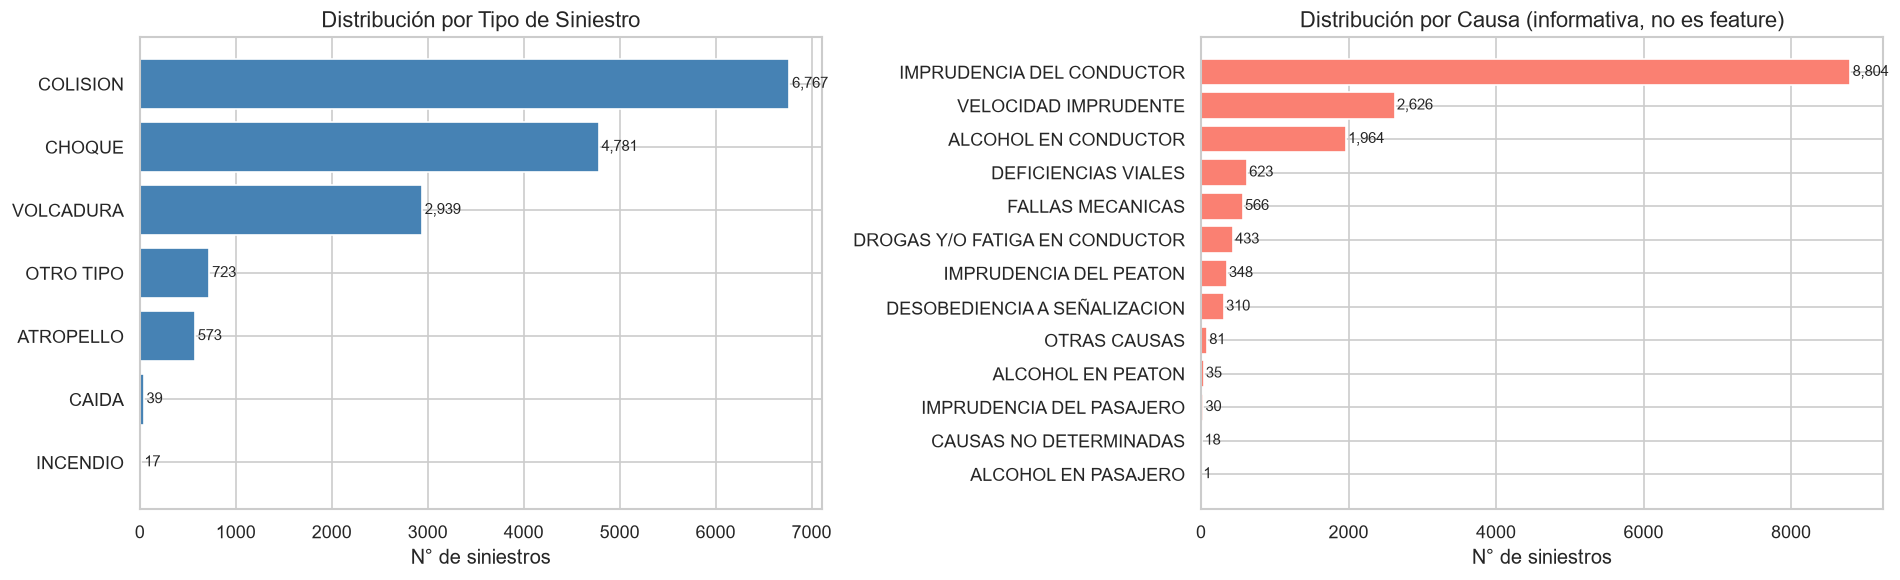

In [9]:
# Gráfico de barras horizontales para las principales categóricas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tipo siniestro
tipo_counts = df["Tipo__CONA"].value_counts()
axes[0].barh(tipo_counts.index[::-1], tipo_counts.values[::-1], color="steelblue")
axes[0].set_title("Distribución por Tipo de Siniestro", fontsize=13)
axes[0].set_xlabel("N° de siniestros")
for i, v in enumerate(tipo_counts.values[::-1]):
    axes[0].text(v + 30, i, f"{v:,}", va='center', fontsize=9)

# Causa
causa_counts = df["Causa__CON"].value_counts()
axes[1].barh(causa_counts.index[::-1], causa_counts.values[::-1], color="salmon")
axes[1].set_title("Distribución por Causa (informativa, no es feature)", fontsize=13)
axes[1].set_xlabel("N° de siniestros")
for i, v in enumerate(causa_counts.values[::-1]):
    axes[1].text(v + 30, i, f"{v:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

REGION_DPA
Maule                                    2582
La Araucanía                             1787
Biobío                                   1766
Libertador General Bernardo O'Higgins    1708
Los Lagos                                1673
Metropolitana de Santiago                1431
Valparaíso                               1177
Coquimbo                                  986
Ñuble                                     914
Los Ríos                                  669
Name: count, dtype: int64


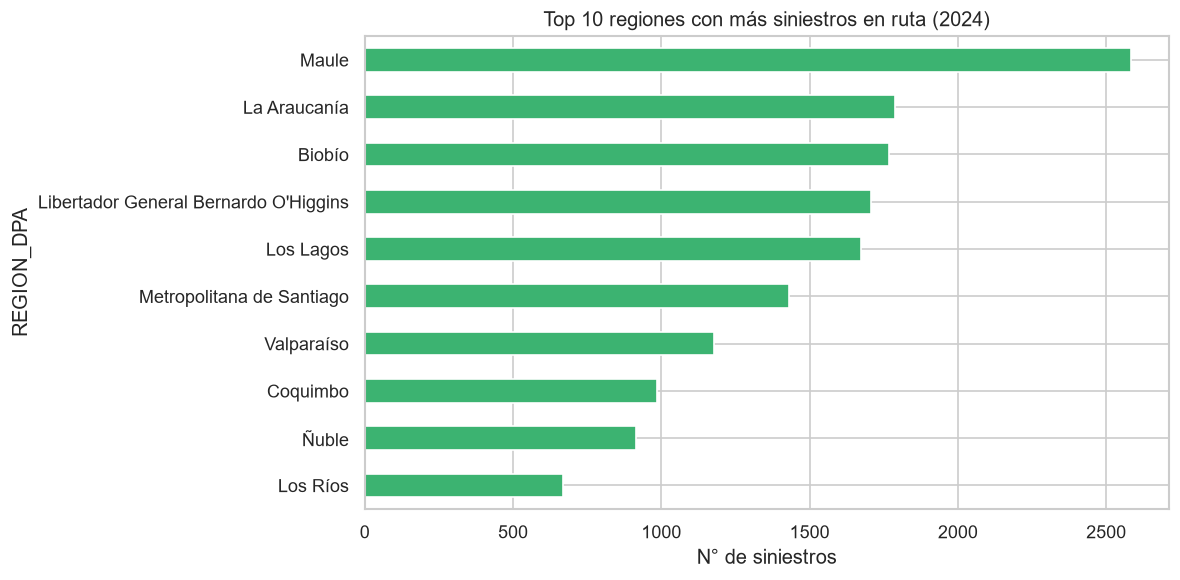

In [10]:
# Top 10 regiones con más siniestros
region_counts = df["REGION_DPA"].value_counts().head(10)
print(region_counts)

region_counts.sort_values().plot(
    kind="barh", figsize=(10, 5),
    title="Top 10 regiones con más siniestros en ruta (2024)",
    color="mediumseagreen"
)
plt.xlabel("N° de siniestros")
plt.tight_layout()
plt.show()

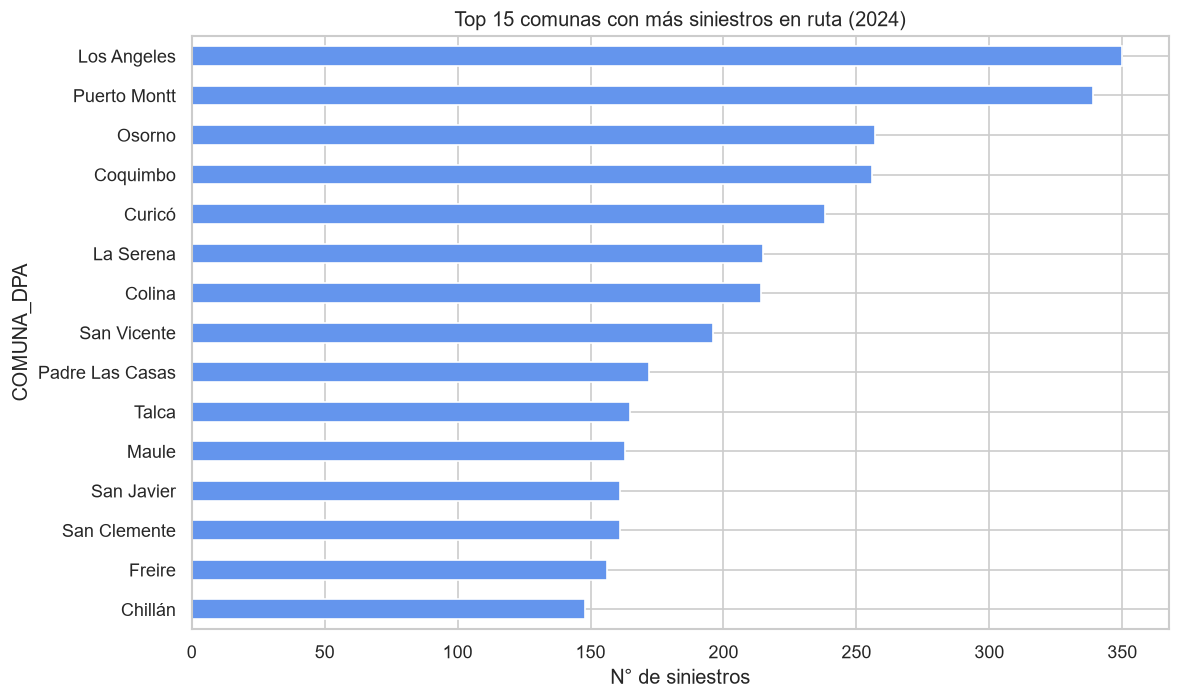

In [11]:
# Top 15 comunas con más siniestros
top_comunas = df["COMUNA_DPA"].value_counts().head(15)
top_comunas.sort_values().plot(
    kind="barh", figsize=(10, 6),
    title="Top 15 comunas con más siniestros en ruta (2024)",
    color="cornflowerblue"
)
plt.xlabel("N° de siniestros")
plt.tight_layout()
plt.show()

**Nota de diseño:**

- `Zona`: si es constante (100% 'RURAL'), se descarta como feature (varianza cero) — pero informa el alcance real del dataset (siniestros en rutas interurbanas, no urbanos).
- `Causa__CON`: determinación investigativa posterior al siniestro (parte policial) → **no usar como feature de entrada al modelo predictivo**, sí usar en el dashboard como variable descriptiva.
- `Tipo__CONA`: describe el hecho ocurrido. Se evalúa si se conoce *antes* o *junto con* el resultado. Se excluye para evitar leakage, ya que es concurrente con la gravedad.
- `Región`/`Comuna` vs `REGION_DPA`/`COMUNA_DPA`: son redundantes, se usa la versión DPA (codificación oficial).

## 4. Análisis temporal

Distribución de siniestros por mes, día de semana y hora aproximada. Buscar patrones (ej. más siniestros de noche, fines de semana, meses de vacaciones).

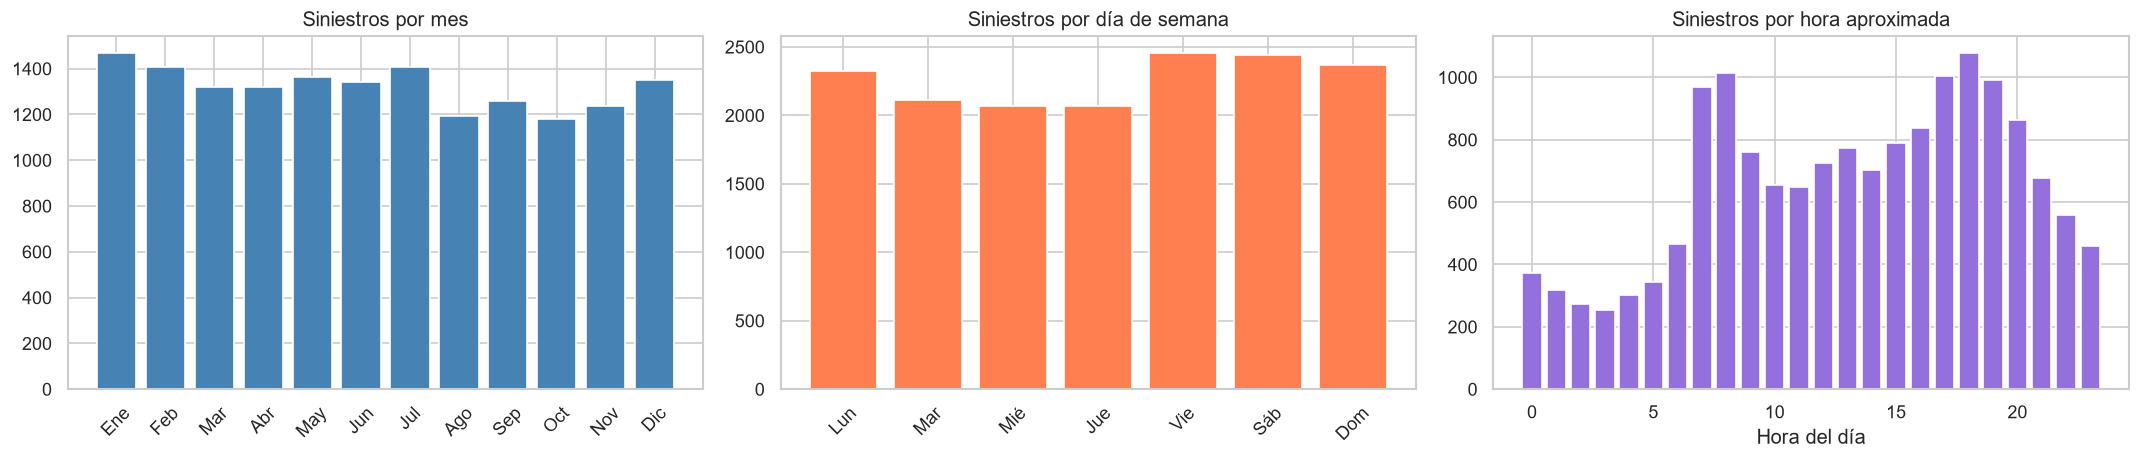

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
mes_counts = df["Mes"].value_counts().sort_index()
axes[0].bar(mes_counts.index, mes_counts.values, color="steelblue")
axes[0].set_title("Siniestros por mes")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(meses, rotation=45)

dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dia_counts = df["Diasemana"].value_counts().sort_index()
axes[1].bar(dia_counts.index, dia_counts.values, color="coral")
axes[1].set_title("Siniestros por día de semana")
axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(dias[:len(dia_counts)], rotation=45)

hora_counts = df["Hora_aprox"].value_counts().sort_index()
axes[2].bar(hora_counts.index, hora_counts.values, color="mediumpurple")
axes[2].set_title("Siniestros por hora aproximada")
axes[2].set_xlabel("Hora del día")

plt.tight_layout()
plt.show()

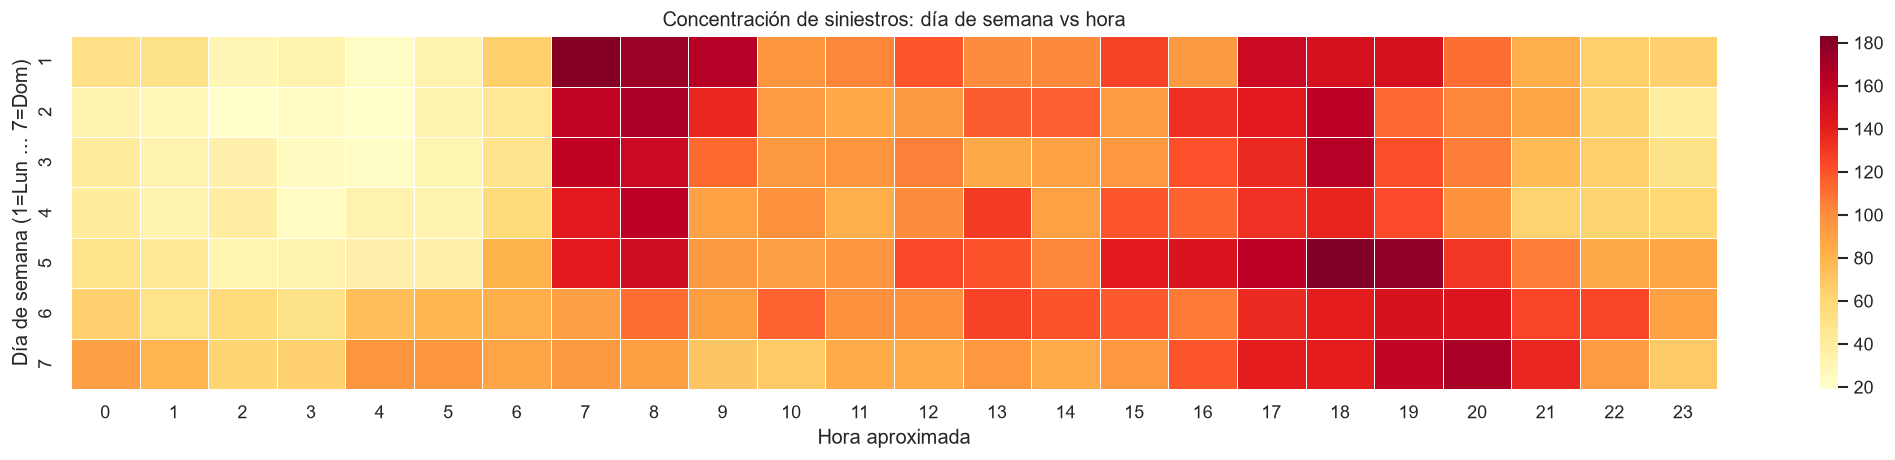

In [13]:
# Heatmap: día de semana vs hora del día
pivot_tiempo = df.pivot_table(
    index="Diasemana",
    columns="Hora_aprox",
    values="IdAccident",
    aggfunc="count",
    fill_value=0
)
plt.figure(figsize=(18, 4))
sns.heatmap(pivot_tiempo, cmap="YlOrRd", linewidths=0.3, annot=False)
plt.title("Concentración de siniestros: día de semana vs hora")
plt.xlabel("Hora aproximada")
plt.ylabel("Día de semana (1=Lun ... 7=Dom)")
plt.tight_layout()
plt.show()

In [14]:
# Feature derivada: fin de semana (si Diasemana=1 es lunes, 6=sáb, 7=dom)
df["es_fin_de_semana"] = df["Diasemana"].isin([6, 7]).astype(int)
print("Distribución fin de semana:")
print(df["es_fin_de_semana"].value_counts().rename({0: 'Semana', 1: 'Fin de semana'}))

# Feature derivada: franja horaria
def franja_horaria(h):
    if 0 <= h < 6: return "Madrugada (0-5)"
    elif 6 <= h < 12: return "Mañana (6-11)"
    elif 12 <= h < 18: return "Tarde (12-17)"
    else: return "Noche (18-23)"

df["franja_horaria"] = df["Hora_aprox"].apply(franja_horaria)
print("\nDistribución por franja horaria:")
print(df["franja_horaria"].value_counts())

Distribución fin de semana:
es_fin_de_semana
Semana           11025
Fin de semana     4814
Name: count, dtype: int64

Distribución por franja horaria:
franja_horaria
Tarde (12-17)      4834
Noche (18-23)      4628
Mañana (6-11)      4513
Madrugada (0-5)    1864
Name: count, dtype: int64


## 5. Construcción y balance de la variable objetivo

La gravedad del siniestro se deriva de las columnas `Fallecidos`, `Graves`, `Menos_Grav`, `Leves`.

In [15]:
# Resumen de columnas de víctimas
cols_victimas = ["Fallecidos", "Graves", "Menos_Grav", "Leves", "Lesionados"]
df[cols_victimas].describe().round(2)

,Fallecidos,Graves,Menos_Grav,Leves,Lesionados
count,15839.00,15839.00,15839.00,15839.00,15839.00
mean,0.05,0.16,0.09,0.69,0.94
std,0.25,0.48,0.36,1.17,1.40
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,1.00
75%,0.00,0.00,0.00,1.00,1.00
max,5.00,8.00,15.00,27.00,36.00


In [16]:
def clasificar_gravedad(row):
    if row["Fallecidos"] > 0:
        return "Fatal"
    elif row["Graves"] > 0:
        return "Grave"
    elif row["Menos_Grav"] > 0 or row["Leves"] > 0:
        return "Leve"
    else:
        return "Sin lesionados"

df["gravedad"] = df.apply(clasificar_gravedad, axis=1)
conteo = df["gravedad"].value_counts()
print(conteo)
print(f"\nProporción:")
print((conteo / len(df) * 100).round(2))

gravedad
Sin lesionados    6958
Leve              6208
Grave             1945
Fatal              728
Name: count, dtype: int64

Proporción:
gravedad
Sin lesionados    43.93
Leve              39.19
Grave             12.28
Fatal              4.60
Name: count, dtype: float64


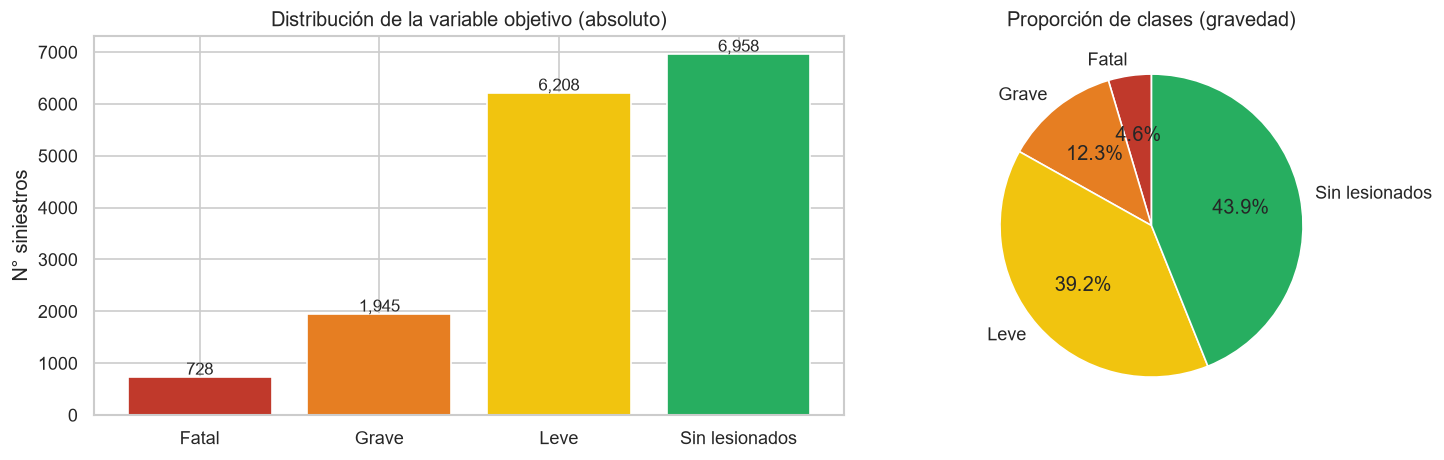

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Conteo absoluto
orden = ["Fatal", "Grave", "Leve", "Sin lesionados"]
colores = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60"]
vals = [df["gravedad"].value_counts().get(g, 0) for g in orden]
axes[0].bar(orden, vals, color=colores)
axes[0].set_title("Distribución de la variable objetivo (absoluto)")
axes[0].set_ylabel("N° siniestros")
for i, v in enumerate(vals):
    axes[0].text(i, v + 50, f"{v:,}", ha='center', fontsize=10)

# Pie chart proporcional
axes[1].pie(vals, labels=orden, colors=colores, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proporción de clases (gravedad)")

plt.tight_layout()
plt.show()

**Nota de diseño:** Si hay desbalance de clases significativo (esperado: pocas filas 'Fatal' vs muchas 'Leve'), se debe documentar la estrategia de modelado:
- `class_weight='balanced'` en Random Forest / Regresión Logística.
- Métricas robustas: F1-macro, AUC-ROC multiclase (OvR).
- Opcionalmente: oversampling con SMOTE en el pipeline de entrenamiento.

## 6. Análisis geográfico

Revisión de la dispersión de coordenadas (`Lat`, `Lon`) — validación de rango de valores y visualización de la distribución espacial de siniestros. Esta información es la que luego se cruza con la API de hospitales (Overpass) para calcular la variable `distancia_hospital_mas_cercano`.

In [18]:
print("Rango de coordenadas:")
df[["Lat", "Lon"]].describe().round(4)

Rango de coordenadas:


,Lat,Lon
count,15839.0000,15839.0000
mean,-35.6754,-71.8172
std,4.5534,1.0143
min,-53.8020,-109.3230
25%,-38.4084,-72.6144
50%,-35.6232,-71.6666
75%,-33.5861,-71.1245
max,-18.0096,-67.2335


In [19]:
# Validar que las coordenadas estén dentro del territorio de Chile
lat_valida = df["Lat"].between(-56, -17)
lon_valida = df["Lon"].between(-76, -66)
invalidos = (~lat_valida | ~lon_valida).sum()
print(f"Registros con coordenadas fuera del rango esperado para Chile: {invalidos}")
print(f"Registros válidos: {(lat_valida & lon_valida).sum():,}")

Registros con coordenadas fuera del rango esperado para Chile: 1
Registros válidos: 15,838


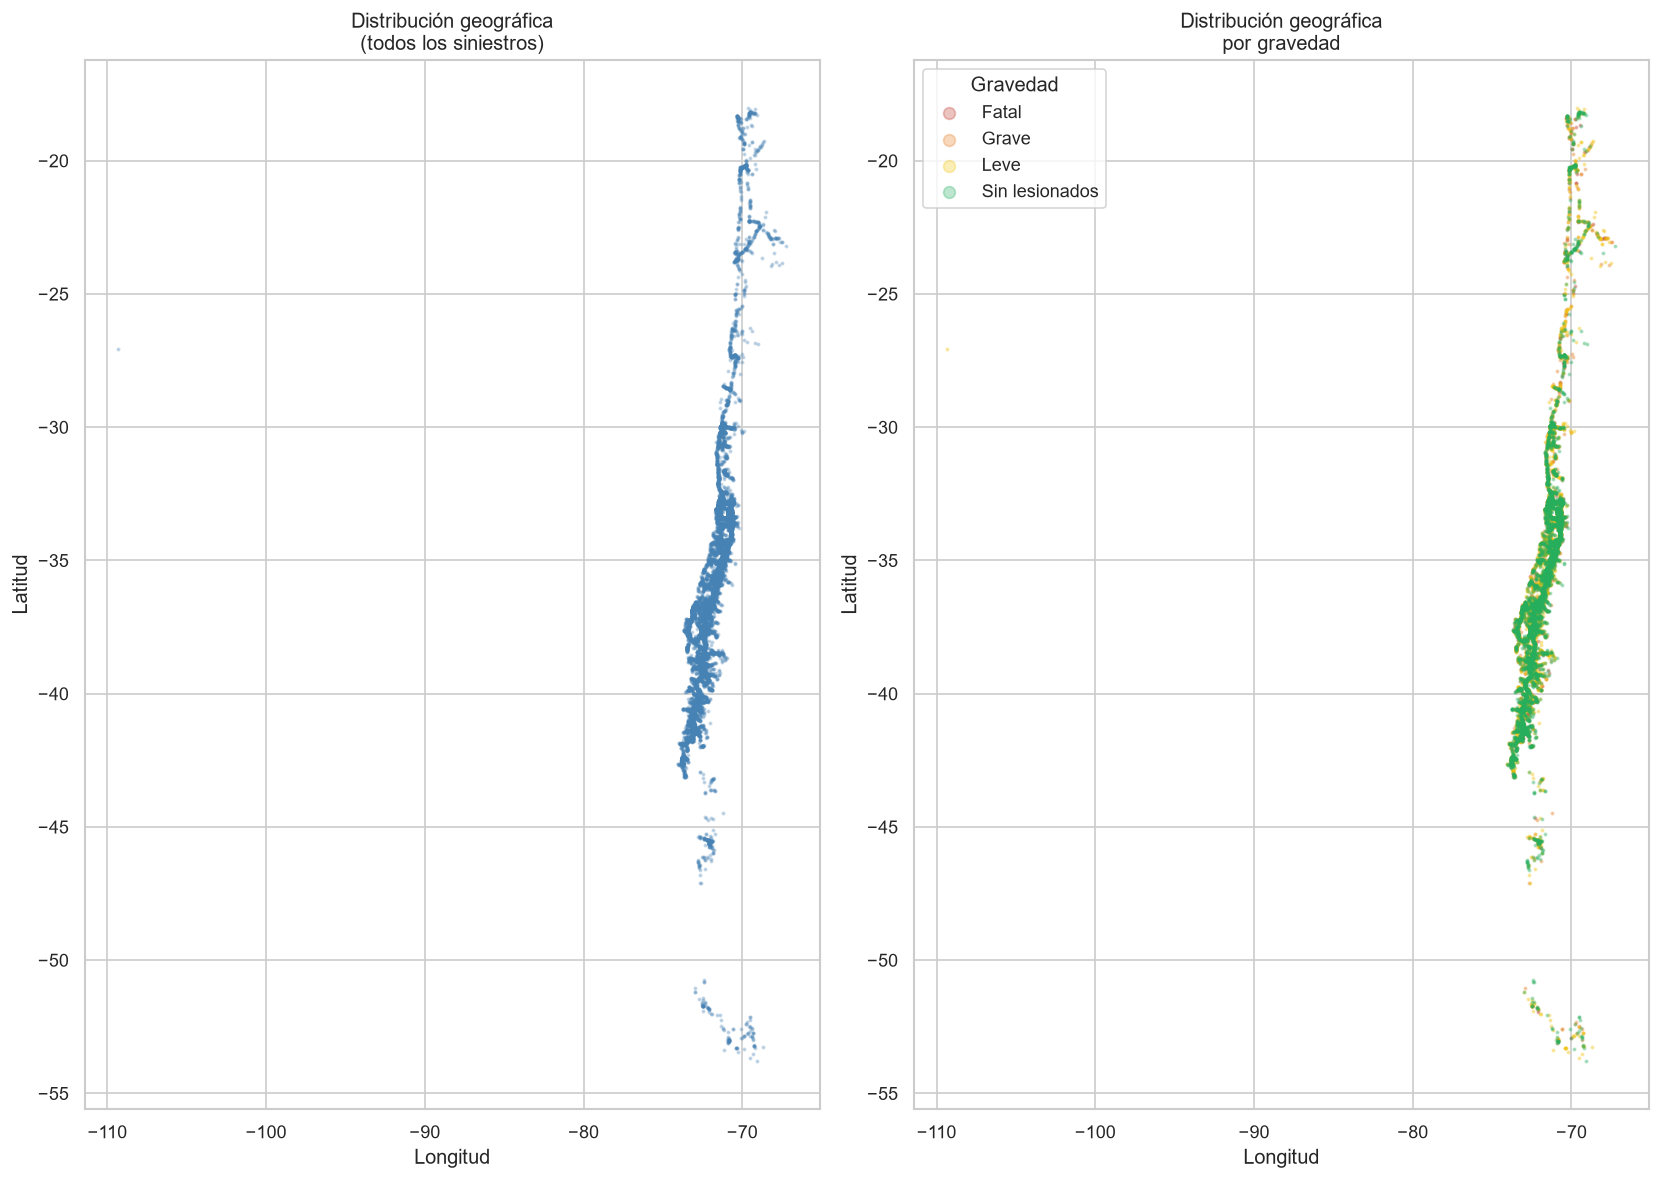

In [20]:
# Scatter geográfico coloreado por gravedad
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Distribución general
axes[0].scatter(df["Lon"], df["Lat"], s=2, alpha=0.25, color="steelblue")
axes[0].set_title("Distribución geográfica\n(todos los siniestros)")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")

# Coloreado por gravedad
color_map = {"Fatal": "#c0392b", "Grave": "#e67e22", "Leve": "#f1c40f", "Sin lesionados": "#27ae60"}
for grav, color in color_map.items():
    sub = df[df["gravedad"] == grav]
    axes[1].scatter(sub["Lon"], sub["Lat"], s=2, alpha=0.3, color=color, label=grav)

axes[1].set_title("Distribución geográfica\npor gravedad")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
axes[1].legend(markerscale=5, title="Gravedad")

plt.tight_layout()
plt.show()

## 7. Gravedad por región y variables temporales

Análisis cruzado de la variable objetivo con las features candidatas: ¿en qué regiones/horarios hay más siniestros fatales?

In [21]:
# Porcentaje de siniestros fatales por región (top 10 regiones)
top_regiones = df["REGION_DPA"].value_counts().head(10).index
df_top = df[df["REGION_DPA"].isin(top_regiones)]

tabla = pd.crosstab(
    df_top["REGION_DPA"],
    df_top["gravedad"],
    normalize="index"
).round(3) * 100

# Reordenar columnas
cols_orden = [c for c in ["Fatal", "Grave", "Leve", "Sin lesionados"] if c in tabla.columns]
tabla = tabla[cols_orden]
tabla.sort_values("Fatal", ascending=False)

gravedad,Fatal,Grave,Leve,Sin lesionados
REGION_DPA,,,,
Ñuble,5.6,13.3,37.7,43.3
Metropolitana de Santiago,5.3,10.8,38.9,45.0
Coquimbo,4.8,10.9,38.2,46.1
Los Ríos,4.6,9.7,43.5,42.2
Los Lagos,4.4,9.7,32.9,53.0
Libertador General Bernardo O'Higgins,4.4,12.3,40.9,42.4
Valparaíso,4.1,13.1,35.9,46.9
Biobío,4.0,13.3,41.0,41.7
La Araucanía,3.9,14.9,39.5,41.7


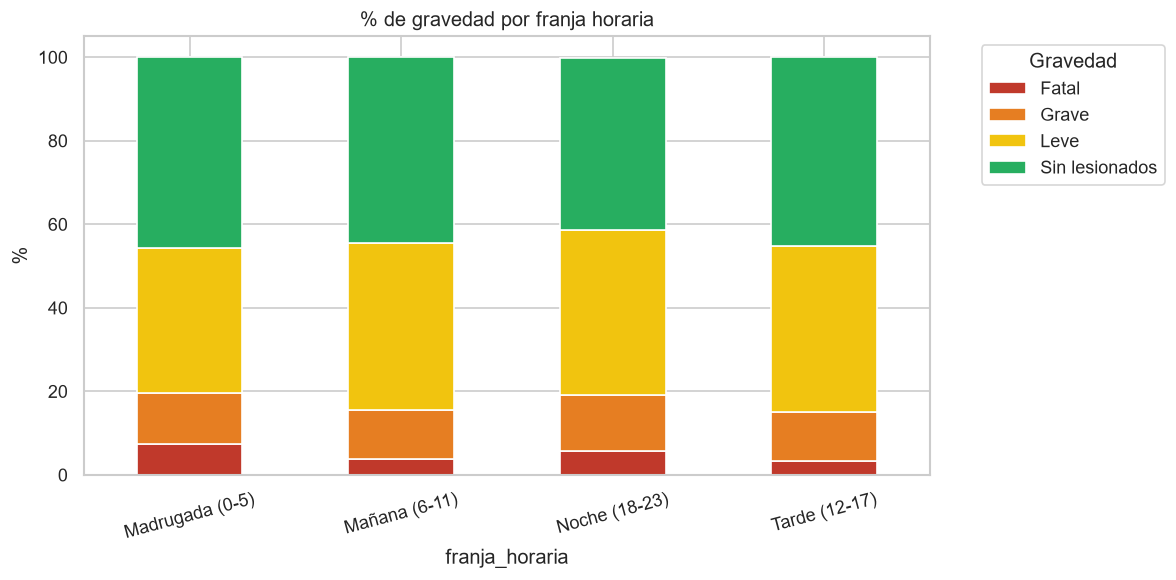

In [22]:
# Gravedad por franja horaria
tabla_hora = pd.crosstab(
    df["franja_horaria"],
    df["gravedad"],
    normalize="index"
).round(3) * 100

cols_orden = [c for c in ["Fatal", "Grave", "Leve", "Sin lesionados"] if c in tabla_hora.columns]
tabla_hora[cols_orden].plot(
    kind="bar", stacked=True, figsize=(10, 5),
    color=["#c0392b", "#e67e22", "#f1c40f", "#27ae60"],
    title="% de gravedad por franja horaria"
)
plt.ylabel("%")
plt.xticks(rotation=15)
plt.legend(title="Gravedad", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 8. Conclusiones y justificación de decisiones

*(Actualizar según resultados observados en las secciones anteriores)*

### Columnas descartadas y por qué
| Columna | Razón |
|---|---|
| `X`, `Y` | Redundantes con `Lat`/`Lon` |
| `FID`, `IdAccident` | Identificadores sin valor predictivo |
| `Zona` | Varianza cero (100% RURAL) |
| `Región`, `Ciudad`, `Comuna` | Redundantes con versión DPA (codificación oficial) |
| `Causa__CON` | Data leakage: determinación posterior al siniestro |
| `Tipo__CONA` | Data leakage: concurrente con la gravedad |
| `Fallecidos`, `Graves`, `Menos_Grav`, `Leves`, `Lesionados` | Directamente derivados de la variable objetivo |

### Features finales propuestas para el modelo
| Feature | Tipo | Descripción |
|---|---|---|
| `Mes` | Numérica | Mes del año (1–12) |
| `Diasemana` | Numérica | Día de la semana (1–7) |
| `es_fin_de_semana` | Binaria (derivada) | 1 si Sáb o Dom |
| `Hora_aprox` | Numérica | Hora del día (0–23) |
| `franja_horaria` | Categórica (derivada) | Madrugada / Mañana / Tarde / Noche |
| `REGION_DPA` | Categórica | Código región oficial |
| `COMUNA_DPA` | Categórica | Código comuna oficial |
| `Lat`, `Lon` | Numéricas | Coordenadas (para calcular distancia al hospital) |
| `distancia_hospital_mas_cercano` | Numérica (a construir en ETL) | Km al hospital más cercano (via API Overpass) |

### Variable objetivo
- **`gravedad`** (Fatal / Grave / Leve / Sin lesionados) — clasificación multiclase ordenada.

### Estrategia ante desbalance de clases
- Usar `class_weight='balanced'` en todos los modelos sklearn.
- Evaluar con F1-macro y AUC-ROC multiclase (OvR), no con accuracy.
- Analizar SMOTE si la clase 'Fatal' queda con representación < 5%.

---
Estas decisiones alimentan directamente el diseño de `/etl/transform.py` y la justificación técnica del informe ejecutivo.